# Phase 2 — 2D Spatial Dynamics: Diffusion, the Poisson Problem, and Cavity Flow

Two dimensions add a qualitatively new ingredient that the [1-D fundamentals](phase1_fundamentals.ipynb) could not show: an **elliptic constraint**. An incompressible flow cannot evolve its vorticity without simultaneously solving a Poisson equation for the streamfunction at every step — a global, instantaneous coupling with no time-step of its own. This chapter builds up to that coupling through 2-D diffusion, the Poisson solve in isolation, and finally the lid-driven cavity, where advection, diffusion, and the elliptic inversion all act together {cite}`durran2010numerical,cushman2011introduction`.

**What you will learn**

- How diffusion smooths a 2-D field on the staggered grid
- Why incompressible dynamics needs an elliptic (Poisson) solve, and what its solution looks like
- How somax's vorticity–streamfunction Navier–Stokes model assembles advection + diffusion + Poisson into the canonical cavity benchmark

## 1. Two-dimensional diffusion

The 2-D diffusion equation smooths a field isotropically,

```{math}
:label: p2-diffusion
\partial_t u = \nu\,\nabla^2 u = \nu\left(\partial_{xx} u + \partial_{yy} u\right),
```

and inherits the parabolic step limit from one dimension in a slightly stricter form, $\nu\,\Delta t\,(\Delta x^{-2} + \Delta y^{-2}) \le 1/2$. A compact blob relaxes into an ever-wider, ever-flatter mound while conserving its integral — the multidimensional version of the smoothing seen in {eq}`p2-diffusion`.

In [1]:
import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import importlib.util
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import (
    Diffusion2D,
    Diffusion2DState,
    IncompressibleNS2D,
    NSVorticityState,
    PoissonSolver2D,
)

In [2]:
try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p numpy,jax,matplotlib,somax")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

watermark extension not installed; skipping reproducibility readout.


In [3]:
IMG_DIR = Path.cwd().parent / "images" / "phase2_spatial"
IMG_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
diff2d = Diffusion2D.create(nx=96, ny=96, Lx=1.0, Ly=1.0, nu=2.0e-3)
xd = jnp.linspace(0.0, 1.0, diff2d.grid.Nx)
yd = jnp.linspace(0.0, 1.0, diff2d.grid.Ny)
Xd, Yd = jnp.meshgrid(xd, yd)
blob0 = jnp.exp(-0.5 * (((Xd - 0.5) / 0.05) ** 2 + ((Yd - 0.5) / 0.05) ** 2))
diff_state0 = diff2d.apply_boundary_conditions(Diffusion2DState(u=blob0))

diff_sol = diff2d.integrate(diff_state0, t0=0.0, t1=8.0, dt=2.0e-3, max_steps=20000)
blob_final = diff_sol.ys.u[-1]

{numref}`p2-diffusion-fig` contrasts the initial spike with the relaxed field.

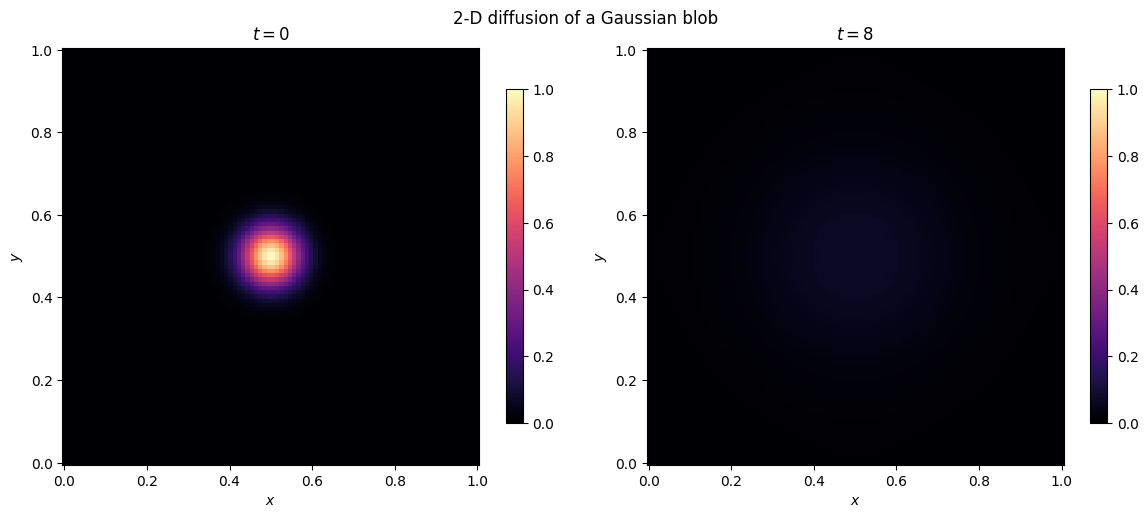

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, field, ttl in zip(axes, [blob0, blob_final], ["$t=0$", "$t=8$"], strict=True):
    im = ax.pcolormesh(Xd, Yd, field, cmap="magma", vmin=0.0, vmax=1.0)
    ax.set(xlabel="$x$", ylabel="$y$", title=ttl, aspect="equal")
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("2-D diffusion of a Gaussian blob")
fig.tight_layout()
fig.savefig(IMG_DIR / "diffusion2d.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase2_spatial/diffusion2d.png
:label: p2-diffusion-fig
:width: 95%

A 2-D Gaussian blob before and after diffusing under {eq}`p2-diffusion`. The peak collapses and the support broadens isotropically.
```

## 2. The Poisson problem — the elliptic heart of incompressible flow

An incompressible 2-D flow is divergence-free, so it derives from a streamfunction $\psi$ with $\mathbf{u} = (-\partial_y\psi,\ \partial_x\psi)$. Its vorticity $\omega = \partial_x v - \partial_y u$ then satisfies a **Poisson equation**,

```{math}
:label: p2-poisson
\nabla^2 \psi = \omega ,
```

which must be solved — globally and instantaneously — to recover the velocity from the vorticity at every time step. Unlike advection or diffusion, {eq}`p2-poisson` has no time derivative: it is an elliptic constraint, and its fast, accurate inversion is the workhorse behind both the Navier–Stokes cavity below and the quasi-geostrophic models of [Phase 4](phase4_gfd.ipynb). somax exposes the inversion directly as `PoissonSolver2D`.

In [6]:
poisson = PoissonSolver2D.create(nx=128, ny=128, Lx=1.0, Ly=1.0, bc="dirichlet")
xp = jnp.linspace(0.0, 1.0, poisson.grid.Nx)
yp = jnp.linspace(0.0, 1.0, poisson.grid.Ny)
Xp, Yp = jnp.meshgrid(xp, yp)

# A localized vorticity source: a positive and a negative blob (a vortex pair).
omega_src = jnp.exp(-((Xp - 0.35) ** 2 + (Yp - 0.5) ** 2) / 0.01) - jnp.exp(
    -((Xp - 0.65) ** 2 + (Yp - 0.5) ** 2) / 0.01
)
psi = poisson.solve(omega_src)
print(
    f"Poisson solve: psi shape {psi.shape}, finite={bool(jnp.all(jnp.isfinite(psi)))}"
)

Poisson solve: psi shape (130, 130), finite=True


{numref}`p2-poisson-fig` shows the source on the left and the recovered streamfunction on the right; the closed $\psi$ contours are the streamlines of the vortex pair that the source implies.

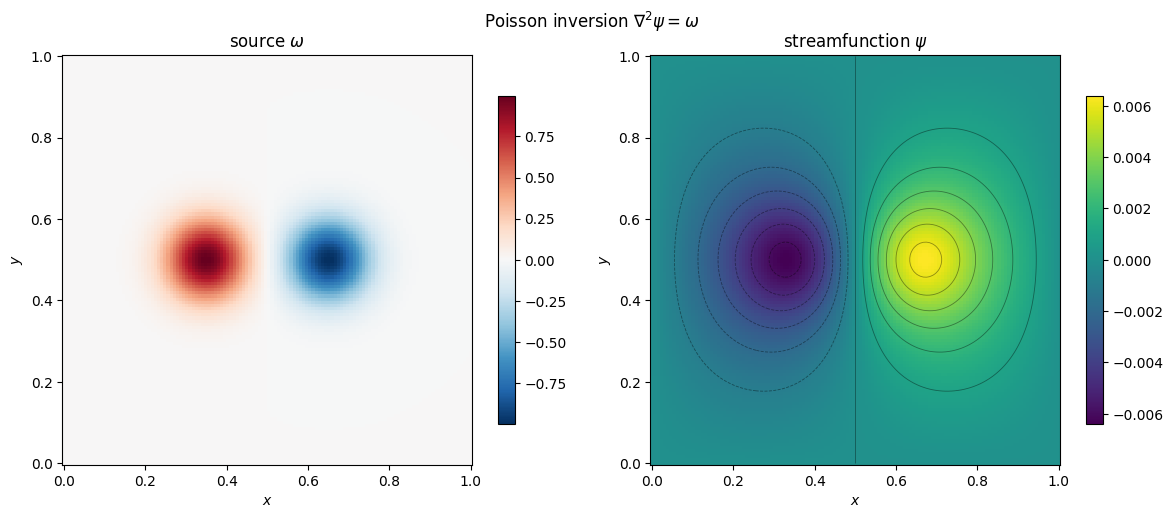

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].pcolormesh(Xp, Yp, omega_src, cmap="RdBu_r")
axes[0].set(xlabel="$x$", ylabel="$y$", title=r"source $\omega$", aspect="equal")
fig.colorbar(im0, ax=axes[0], shrink=0.8)
im1 = axes[1].pcolormesh(Xp, Yp, psi, cmap="viridis")
axes[1].contour(Xp, Yp, psi, levels=12, colors="k", alpha=0.4, linewidths=0.6)
axes[1].set(xlabel="$x$", ylabel="$y$", title=r"streamfunction $\psi$", aspect="equal")
fig.colorbar(im1, ax=axes[1], shrink=0.8)
fig.suptitle(r"Poisson inversion $\nabla^2\psi=\omega$")
fig.tight_layout()
fig.savefig(IMG_DIR / "poisson.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase2_spatial/poisson.png
:label: p2-poisson-fig
:width: 95%

Left: a dipolar vorticity source. Right: the streamfunction recovered by inverting {eq}`p2-poisson` with homogeneous Dirichlet boundaries; the contours are the implied streamlines.
```

## 3. Lid-driven cavity — advection, diffusion, and Poisson together

The lid-driven cavity is the standard benchmark that exercises all three ingredients at once. The vorticity transport equation

```{math}
:label: p2-cavity
\partial_t \omega + \mathbf{u}\cdot\nabla\omega = \nu\,\nabla^2\omega ,
\qquad \nabla^2\psi = \omega ,
```

is integrated in a square box whose top wall slides at constant speed while the other three are no-slip. Vorticity is generated at the moving lid, advected into the interior, diffused, and continuously re-inverted through {eq}`p2-cavity` to update the velocity. somax's `IncompressibleNS2D` assembles exactly this loop.

In [8]:
cavity = IncompressibleNS2D.create(
    nx=96, ny=96, Lx=1.0, Ly=1.0, nu=2.0e-3, problem="cavity", u_lid=1.0
)
cav_state0 = cavity.apply_boundary_conditions(
    NSVorticityState(omega=jnp.zeros((cavity.grid.Ny, cavity.grid.Nx)))
)
cav_sol = cavity.integrate(cav_state0, t0=0.0, t1=5.0, dt=2.5e-3, max_steps=20000)
omega_final = cav_sol.ys.omega[-1]
psi_final = cavity._solve_psi(omega_final)
print(f"cavity Reynolds number ~ u_lid*L/nu = {1.0 * 1.0 / 2.0e-3:.0f}")

cavity Reynolds number ~ u_lid*L/nu = 500


{numref}`p2-cavity-fig` shows the spun-up cavity: the primary recirculating vortex fills the box, driven by the lid, with the streamfunction contours revealing the characteristic central eddy and weaker bottom-corner circulations.

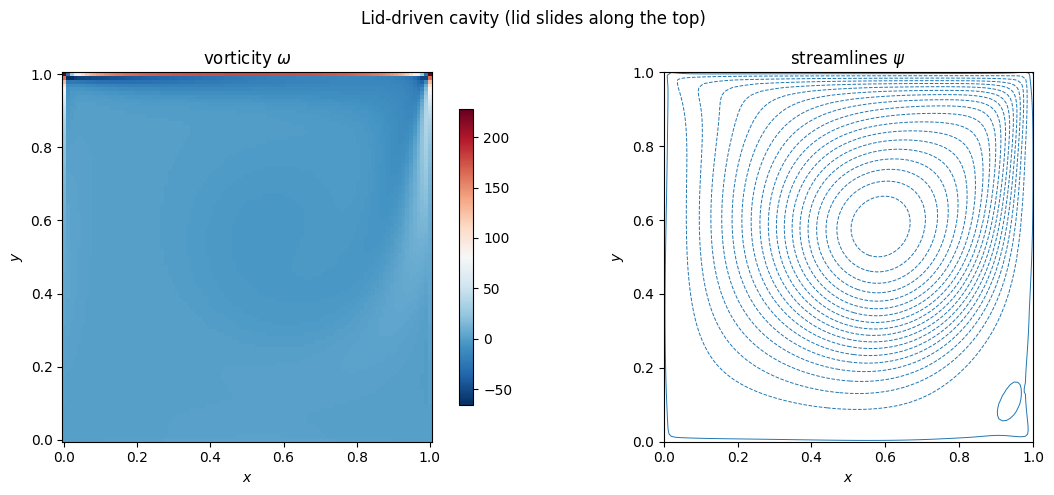

In [9]:
xc = jnp.linspace(0.0, 1.0, cavity.grid.Nx)
yc = jnp.linspace(0.0, 1.0, cavity.grid.Ny)
Xc, Yc = jnp.meshgrid(xc, yc)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].pcolormesh(Xc, Yc, omega_final, cmap="RdBu_r")
axes[0].set(xlabel="$x$", ylabel="$y$", title=r"vorticity $\omega$", aspect="equal")
fig.colorbar(im0, ax=axes[0], shrink=0.8)
axes[1].contour(Xc, Yc, psi_final, levels=20, colors="C0", linewidths=0.7)
axes[1].set(xlabel="$x$", ylabel="$y$", title=r"streamlines $\psi$", aspect="equal")
fig.suptitle("Lid-driven cavity (lid slides along the top)")
fig.tight_layout()
fig.savefig(IMG_DIR / "cavity.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase2_spatial/cavity.png
:label: p2-cavity-fig
:width: 95%

Lid-driven cavity at moderate Reynolds number. Left: vorticity, generated at the sliding top wall and swept around the box. Right: streamlines from the Poisson inversion {eq}`p2-cavity`, showing the primary central vortex.
```

## Summary

- 2-D diffusion {eq}`p2-diffusion` smooths isotropically under a parabolic step limit, the direct extension of the 1-D case.
- Incompressible flow carries an **elliptic constraint**: the Poisson equation {eq}`p2-poisson` must be inverted every step to recover velocity from vorticity — a global coupling with no time-step of its own, exposed as `PoissonSolver2D`.
- The lid-driven cavity {eq}`p2-cavity` welds advection, diffusion, and the Poisson solve into one loop; the same vorticity–streamfunction structure reappears in the quasi-geostrophic ocean models.

With the elliptic machinery in place, the [next chapter](phase3_chaos.ipynb) turns to low-order **chaos** — the Lorenz systems — before [Phase 4](phase4_gfd.ipynb) assembles the full geophysical models.